# Notebook 2 — Bayesian Hyperparameter Tuning (Multi-Dataset)

Ottimizzazione bayesiana degli iperparametri di **ResiDual CLAP** su più dataset:
- `n_components_ratio` — frazione di componenti PCA da usare
- `target_layers`      — quali layer del transformer applicare il reweighting

**Strategia:**
- Gaussian Process Regression come surrogate model (scikit-optimize)
- Acquisition function: Expected Improvement
- Baseline CLAP calcolata una volta per dataset
- Checkpoint JSON per riprendere da trial interrotti
- Report separato per dataset + summary comparativo finale

In [1]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
#!pip install scikit-optimize --quiet

In [2]:
# ============================================================
# IMPORTS
# ============================================================
import sys
import os
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import datetime
from copy import deepcopy

from models.residual_clap_utils import (
    BayesianHPTuner,
    build_clap,
    evaluate_model,
    accuracy,
    get_dataset_registry,
    plot_hp_results,
    print_hp_table,
    build_pca_loader,
    fit_pca,
)

print("✅ Import completati")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

✅ Import completati
Device: cpu


In [3]:
# ============================================================
# CONFIGURAZIONE GLOBALE
# ============================================================

# --- Dataset da valutare ---
DATASETS_TO_EVAL = {
    'ESC50':      '../data',
    'VocalSound': '../data',
    'TinySOL':    '../data',
    'IRMAS':      '../data',
}

PROMPT       = 'this is the sound of '
CLAP_VERSION = '2023'
RANDOM_STATE = 42

# --- Parametri ottimizzazione ---
N_CALLS          = 30    # Numero totale di trial (inclusi initial_points)
N_INITIAL_POINTS = 6     # Trial random iniziali (exploration)
EVAL_SAMPLES     = 500  # Campioni per valutare ogni configurazione
PCA_SAMPLES      = 200   # Campioni per fitting PCA

# --- Spazio di ricerca (condiviso tra tutti i dataset) ---
PARAM_SPACE = {
    'n_components_ratio': (0.05, 0.50),
    'target_layers_options': [
        [0],
        [1],
        [2],
        [3],
        [0, 1],
        [1, 2],
        [2, 3],
        [0, 1, 2],
        [1, 2, 3],
        [0, 1, 2, 3],
    ],
}

# --- Config base ResiDual (n_components_ratio e target_layers
#     saranno sovrascritti dall'optimizer ad ogni trial) ---
BASE_RESIDUAL_CONFIG = {
    'mode': 'attention',
    'whitening_strength': 1.0,
    'whitening_eps': 1e-6,
    'n_components_ratio': 0.15,
    'target_layers': [3],
}

# --- Paths ---
RESULTS_DIR     = Path('../results')
CHECKPOINTS_DIR = RESULTS_DIR / 'checkpoints'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

print("Configurazione Multi-Dataset HP Tuning:")
print(f"  Dataset:          {list(DATASETS_TO_EVAL.keys())}")
print(f"  N_CALLS:          {N_CALLS}")
print(f"  N_INITIAL_POINTS: {N_INITIAL_POINTS}")
print(f"  EVAL_SAMPLES:     {EVAL_SAMPLES}")
print(f"  PCA_SAMPLES:      {PCA_SAMPLES}")
print(f"  Checkpoints:      {CHECKPOINTS_DIR}")

Configurazione Multi-Dataset HP Tuning:
  Dataset:          ['ESC50', 'VocalSound', 'TinySOL', 'IRMAS']
  N_CALLS:          30
  N_INITIAL_POINTS: 6
  EVAL_SAMPLES:     500
  PCA_SAMPLES:      200
  Checkpoints:      ../results/checkpoints


In [4]:
# ============================================================
# UTILITY — CHECKPOINT
# ============================================================

def checkpoint_path(dataset_name: str) -> Path:
    """Restituisce il path del checkpoint JSON per un dataset."""
    return CHECKPOINTS_DIR / f'checkpoint_{dataset_name}.json'


def load_checkpoint(dataset_name: str) -> dict | None:
    """
    Carica checkpoint se esiste.
    
    Returns:
        dict con chiavi 'baseline_acc', 'all_results', 'completed_trials'
        oppure None se non esiste.
    """
    cp = checkpoint_path(dataset_name)
    if cp.exists():
        with open(cp, 'r') as f:
            data = json.load(f)
        print(f"  📂 Checkpoint trovato: {len(data['all_results'])} trial già completati")
        return data
    return None


def save_checkpoint(dataset_name: str, baseline_acc: float, all_results: list):
    """
    Salva checkpoint dopo ogni trial completato.
    
    Args:
        dataset_name:  nome del dataset
        baseline_acc:  accuracy baseline CLAP standard
        all_results:   lista di dict con tutti i trial completati finora
    """
    cp = checkpoint_path(dataset_name)
    data = {
        'dataset': dataset_name,
        'saved_at': datetime.now().isoformat(),
        'baseline_acc': float(baseline_acc),
        'completed_trials': len(all_results),
        'all_results': [
            {
                'trial':              r['trial'],
                'n_components_ratio': float(r['n_components_ratio']),
                'target_layers':      r['target_layers'],
                'accuracy':           float(r['accuracy']),
                'delta_vs_baseline':  float(r['delta_vs_baseline']),
            }
            for r in all_results
        ],
    }
    with open(cp, 'w') as f:
        json.dump(data, f, indent=2)


def delete_checkpoint(dataset_name: str):
    """Rimuove il checkpoint una volta che l'ottimizzazione è completata."""
    cp = checkpoint_path(dataset_name)
    if cp.exists():
        cp.unlink()
        print(f"  🗑️  Checkpoint {dataset_name} rimosso (ottimizzazione completata)")

In [5]:
# ============================================================
# UTILITY — SINGLE DATASET OPTIMIZATION
# ============================================================

def run_optimization_for_dataset(
    dataset_name: str,
    dataset_root: str,
) -> dict:
    """
    Esegue Bayesian HP tuning completo per un singolo dataset.
    
    Gestisce:
    - Caricamento dataset
    - Calcolo baseline (saltato se checkpoint presente)
    - Ottimizzazione con resume da checkpoint
    - Salvataggio report individuale
    
    Args:
        dataset_name: chiave nel registry
        dataset_root: path radice dati

    Returns:
        result dict con tutte le info del dataset
    """
    print(f"\n{'='*70}")
    print(f"  DATASET: {dataset_name}")
    print(f"{'='*70}")

    # ---- Carica dataset ----
    DATASET_REGISTRY = get_dataset_registry()
    if dataset_name not in DATASET_REGISTRY:
        raise ValueError(
            f"Dataset '{dataset_name}' non trovato nel registry. "
            f"Disponibili: {list(DATASET_REGISTRY.keys())}"
        )

    dataset = DATASET_REGISTRY[dataset_name](root=dataset_root, download=False)
    text_labels = [PROMPT + x for x in dataset.classes]

    print(f"  Campioni: {len(dataset)}  |  Classi: {len(dataset.classes)}")

    use_cuda = torch.cuda.is_available()

    # ---- Indici fissi per evaluation ----
    rng = np.random.RandomState(RANDOM_STATE)
    eval_indices = rng.choice(
        len(dataset),
        size=min(EVAL_SAMPLES, len(dataset)),
        replace=False,
    ).tolist()

    # ---- Controlla checkpoint ----
    checkpoint = load_checkpoint(dataset_name)

    if checkpoint is not None:
        # Riprendi da checkpoint
        baseline_acc  = checkpoint['baseline_acc']
        prior_results = checkpoint['all_results']
        n_completed   = len(prior_results)
        print(f"  ▶ Ripresa da trial {n_completed + 1}/{N_CALLS}")
        print(f"  ▶ Baseline (da checkpoint): {baseline_acc:.4f}")
    else:
        # Calcola baseline da zero
        prior_results = []
        n_completed   = 0

        print(f"\n  Calcolo baseline CLAP standard...")
        clap_std = build_clap(
            model_type='classic',
            version=CLAP_VERSION,
            use_cuda=use_cuda,
        )
        y_preds_b, y_labels_b = evaluate_model(
            wrapper=clap_std,
            dataset=dataset,
            text_labels=text_labels,
            indices=eval_indices,
            desc=f"Baseline {dataset_name}",
        )
        baseline_acc = accuracy(y_preds_b, y_labels_b)
        del clap_std
        if use_cuda:
            torch.cuda.empty_cache()

        print(f"  ✅ Baseline: {baseline_acc:.4f} ({baseline_acc*100:.1f}%)")

        # Salva subito il checkpoint con solo la baseline
        save_checkpoint(dataset_name, baseline_acc, [])

    # ---- Bayesian Optimization ----
    # Numero di trial rimanenti
    n_remaining = N_CALLS - n_completed

    if n_remaining <= 0:
        print(f"  ✅ Ottimizzazione già completata ({n_completed}/{N_CALLS} trial)")
        all_results = prior_results
    else:
        print(f"\n  Avvio ottimizzazione: {n_remaining} trial rimanenti...")

        tuner = BayesianHPTuner(
            dataset=dataset,
            text_labels=text_labels,
            base_residual_config=BASE_RESIDUAL_CONFIG,
            param_space=PARAM_SPACE,
            n_calls=N_CALLS,
            n_initial_points=N_INITIAL_POINTS,
            eval_samples=EVAL_SAMPLES,
            pca_samples=PCA_SAMPLES,
            clap_version=CLAP_VERSION,
            use_cuda=use_cuda,
            random_state=RANDOM_STATE,
            # Callback chiamato dopo ogni trial → aggiorna checkpoint
            trial_callback=lambda results: save_checkpoint(
                dataset_name, baseline_acc, results
            ),
        )

        # Inietta baseline e trial già completati
        tuner._baseline_acc  = baseline_acc
        tuner._prior_results = prior_results   # BayesianHPTuner deve supportare questo

        best_params, best_score, new_results = tuner.run(verbose=True)

        # Unisci prior + new (nel caso di resume)
        all_results = prior_results + [
            r for r in new_results
            if r['trial'] > n_completed
        ]

    # ---- Best config dai risultati completi ----
    best_result = max(all_results, key=lambda r: r['accuracy'])
    best_params = {
        'n_components_ratio': best_result['n_components_ratio'],
        'target_layers':      best_result['target_layers'],
    }
    best_score = best_result['accuracy']

    # ---- Validazione configurazione ottimale ----
    print(f"\n  Validazione configurazione ottimale...")
    print(f"    n_components_ratio = {best_params['n_components_ratio']:.4f}")
    print(f"    target_layers      = {best_params['target_layers']}")

    val_rng     = np.random.RandomState(RANDOM_STATE + 999)
    val_indices = val_rng.choice(
        len(dataset),
        size=min(EVAL_SAMPLES, len(dataset)),
        replace=False,
    ).tolist()

    optimal_config = deepcopy(BASE_RESIDUAL_CONFIG)
    optimal_config.update(best_params)

    clap_optimal = build_clap(
        model_type='residual',
        residual_config=optimal_config,
        version=CLAP_VERSION,
        use_cuda=use_cuda,
    )
    pca_loader = build_pca_loader(
        wrapper=clap_optimal,
        dataset=dataset,
        max_samples=PCA_SAMPLES,
    )
    fit_pca(clap_optimal, pca_loader, max_samples=PCA_SAMPLES)

    y_preds_opt, y_labels_val = evaluate_model(
        wrapper=clap_optimal,
        dataset=dataset,
        text_labels=text_labels,
        indices=val_indices,
        desc=f"Validazione {dataset_name}",
    )
    val_acc = accuracy(y_preds_opt, y_labels_val)

    del clap_optimal
    if use_cuda:
        torch.cuda.empty_cache()

    print(f"  ✅ Validation accuracy: {val_acc:.4f}  (Δ = {val_acc - baseline_acc:+.4f})")

    # ---- Salva report individuale ----
    report = {
        'dataset':         dataset_name,
        'timestamp':       datetime.now().isoformat(),
        'clap_version':    CLAP_VERSION,
        'optimization_params': {
            'n_calls':          N_CALLS,
            'n_initial_points': N_INITIAL_POINTS,
            'eval_samples':     EVAL_SAMPLES,
            'pca_samples':      PCA_SAMPLES,
        },
        'param_space': {
            'n_components_ratio':    list(PARAM_SPACE['n_components_ratio']),
            'target_layers_options': PARAM_SPACE['target_layers_options'],
        },
        'baseline_accuracy':      float(baseline_acc),
        'best_params':            best_params,
        'best_score_during_opt':  float(best_score),
        'validation_accuracy':    float(val_acc),
        'delta_validation':       float(val_acc - baseline_acc),
        'all_trials': [
            {
                'trial':              r['trial'],
                'n_components_ratio': float(r['n_components_ratio']),
                'target_layers':      r['target_layers'],
                'accuracy':           float(r['accuracy']),
                'delta_vs_baseline':  float(r['delta_vs_baseline']),
            }
            for r in all_results
        ],
    }

    report_path = RESULTS_DIR / f'hp_tuning_{dataset_name}.json'
    with open(report_path, 'w') as f:
        json.dump(report, f, indent=2)
    print(f"  💾 Report salvato: {report_path.name}")

    # ---- Plot individuale ----
    _plot_individual(dataset_name, all_results, baseline_acc, best_score)

    # ---- Rimuovi checkpoint (ottimizzazione completata) ----
    delete_checkpoint(dataset_name)

    return {
        'dataset':        dataset_name,
        'baseline_acc':   baseline_acc,
        'best_score':     best_score,
        'val_acc':        val_acc,
        'delta':          val_acc - baseline_acc,
        'best_params':    best_params,
        'all_results':    all_results,
        'n_classes':      len(dataset.classes),
        'n_samples':      len(dataset),
    }

In [6]:
# ============================================================
# UTILITY — PLOT INDIVIDUALE PER DATASET
# ============================================================

def _plot_individual(
    dataset_name: str,
    all_results: list,
    baseline_acc: float,
    best_score: float,
):
    """Genera e salva i plot di convergenza per un singolo dataset."""

    sorted_results = sorted(all_results, key=lambda x: x['trial'])
    accs           = [r['accuracy'] for r in sorted_results]
    best_so_far    = [max(accs[:i+1]) for i in range(len(accs))]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(
        f'HP Tuning — {dataset_name}\n'
        f'Baseline: {baseline_acc:.3f}  |  Best: {best_score:.3f}  '
        f'(Δ={best_score - baseline_acc:+.3f})',
        fontsize=11,
    )

    # Convergenza
    ax = axes[0]
    ax.plot(range(1, len(accs)+1), accs, 'o-', alpha=0.5,
            color='coral', markersize=4, label='Trial accuracy')
    ax.plot(range(1, len(best_so_far)+1), best_so_far, 'g-',
            linewidth=2, label='Best so far')
    ax.axhline(baseline_acc, color='steelblue', linestyle='--',
               label=f'Baseline ({baseline_acc:.3f})')
    ax.axvline(N_INITIAL_POINTS, color='gray', linestyle=':',
               alpha=0.7, label=f'Fine random ({N_INITIAL_POINTS})')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Accuracy')
    ax.set_title('Convergenza')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Scatter n_components_ratio
    ax2 = axes[1]
    comp_vals = [r['n_components_ratio'] for r in sorted_results]
    layer_str = [str(r['target_layers']) for r in sorted_results]
    unique_layers = sorted(set(layer_str))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_layers)))
    color_map = {l: c for l, c in zip(unique_layers, colors)}

    for r, cv, ls in zip(sorted_results, comp_vals, layer_str):
        ax2.scatter(cv, r['accuracy'], color=color_map[ls], alpha=0.7, s=40)

    # Legenda layers
    for ls, c in color_map.items():
        ax2.scatter([], [], color=c, label=ls, s=30)
    ax2.axhline(baseline_acc, color='steelblue', linestyle='--', alpha=0.7)
    ax2.set_xlabel('n_components_ratio')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy per configurazione')
    ax2.legend(fontsize=6, title='target_layers', bbox_to_anchor=(1.05, 1))
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    out_path = RESULTS_DIR / f'hp_tuning_{dataset_name}_plot.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  📊 Plot salvato: {out_path.name}")
    plt.close()


  DATASET: ESC50
Loading audio files


100%|██████████| 2000/2000 [00:00<00:00, 15701.59it/s]

✓ Cache di validazione trovata (2026-04-01T21:46:58.127961): 2000 validi, 0 corrotti. Skip validazione.
  Campioni: 2000  |  Classi: 50
  📂 Checkpoint trovato: 0 trial già completati
  ▶ Ripresa da trial 1/30
  ▶ Baseline (da checkpoint): 0.9365

  Avvio ottimizzazione: 30 trial rimanenti...



BAYESIAN HYPERPARAMETER OPTIMIZATION
  n_calls totali:   30  (già completati: 0, rimanenti: 30)
  n_initial_points: 6
  eval_samples:     500
  pca_samples:      200
  n_comp_ratio:     [0.05, 0.5]
  target_layers options: [[0], [1], [2], [3], [0, 1], [1, 2], [2, 3], [0, 1, 2], [1, 2, 3], [0, 1, 2, 3]]


--- Trial 1/30 ---
  n_components_ratio = 0.4084
  target_layers      = [2]


  Trial 1: 100%|██████████| 500/500 [02:15<00:00,  3.70it/s]

...

  Accuracy: 0.9360  (delta vs baseline: -0.0005)

RISULTATI OTTIMIZZAZIONE
  Best n_components_ratio: 0.0500
  Best target_layers:      [1]
  Best accuracy:           0.9440
  Baseline accuracy:       0.9365
  Delta:                   +0.0075

  Validazione configurazione ottimale...
    n_components_ratio = 0.0500
    target_layers      = [1]

🔧 Setup ResiDual HTSAT
Modalità: ATTENTION
Target layers: [1]
PCA components ratio: 0.05

✓ layer_1:
  Modalità: PER-HEAD reweighting
  Num blocks: 2
  Heads per block: 8
  Total heads: 16
  Head dim: 24D → 1 PCs



📊 Fitting Spectral Layers
Modalità: ATTENTION
Target layers: [1]
Max samples: 200

📦 Fase 1: Raccolta hidden states...


Raccolta: 100%|██████████| 50/50 [00:39<00:00,  1.26it/s, samples=200]



✓ Raccolti 200 samples totali

🔬 Fase 2: Calcolo PCA e inizializzazione pesi...


layer_1:

  Block 0:
    ✓ head_0: shape=torch.Size([204800, 24]), var=['0.249'], cum=0.249
    ✓ head_1: shape=torch.Size([204800, 24]), var=['0.295'], cum=0.295
    ✓ head_2: shape=torch.Size([204800, 24]), var=['0.205'], cum=0.205
    ✓ head_3: shape=torch.Size([204800, 24]), var=['0.420'], cum=0.420
    ✓ head_4: shape=torch.Size([204800, 24]), var=['0.438'], cum=0.438
    ✓ head_5: shape=torch.Size([204800, 24]), var=['0.219'], cum=0.219
    ✓ head_6: shape=torch.Size([204800, 24]), var=['0.695'], cum=0.695
    ✓ head_7: shape=torch.Size([204800, 24]), var=['0.300'], cum=0.300

  Block 1:
    ✓ head_0: shape=torch.Size([204800, 24]), var=['0.261'], cum=0.261
    ✓ head_1: shape=torch.Size([204800, 24]), var=['0.196'], cum=0.196
    ✓ head_2: shape=torch.Size([204800, 24]), var=['0.223'], cum=0.223
    ✓ head_3: shape=torch.Size([204800, 24]), var=['0.177'], cum=0.177
    ✓ head_4: shape=torch.Size([

Validazione ESC50: 100%|██████████| 500/500 [01:56<00:00,  4.30it/s]


  ✅ Validation accuracy: 0.9340  (Δ = -0.0025)
  💾 Report salvato: hp_tuning_ESC50.json


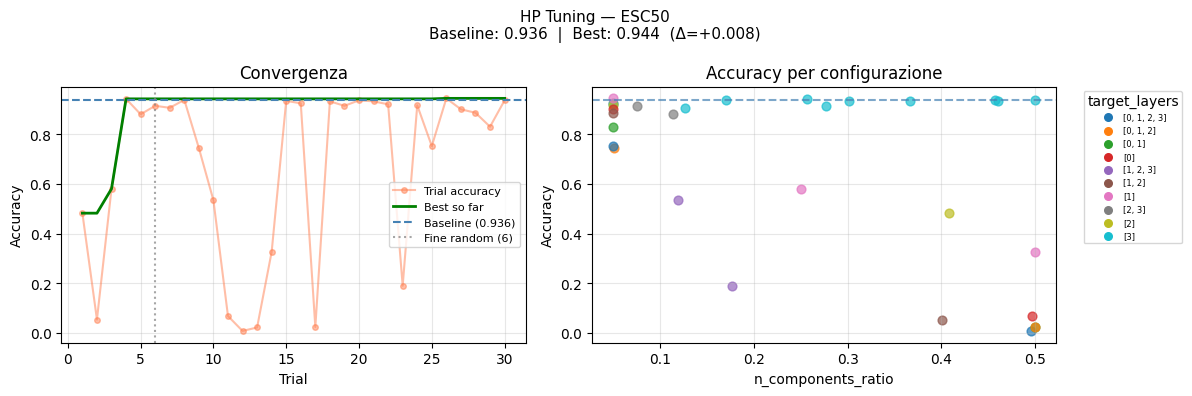

  📊 Plot salvato: hp_tuning_ESC50_plot.png
  🗑️  Checkpoint ESC50 rimosso (ottimizzazione completata)

  ⏱️  ESC50 completato in 91.5 minuti

  DATASET: VocalSound
Loading audio files


100%|██████████| 21024/21024 [00:01<00:00, 17537.62it/s]


✓ Cache di validazione trovata (2026-04-02T01:44:11.836275): 20985 validi, 39 corrotti. Skip validazione.
  Campioni: 20985  |  Classi: 6

  Calcolo baseline CLAP standard...


Baseline VocalSound: 100%|██████████| 500/500 [02:02<00:00,  4.07it/s]


  ✅ Baseline: 0.7360 (73.6%)

  Avvio ottimizzazione: 30 trial rimanenti...

BAYESIAN HYPERPARAMETER OPTIMIZATION
  n_calls totali:   30  (già completati: 0, rimanenti: 30)
  n_initial_points: 6
  eval_samples:     500
  pca_samples:      200
  n_comp_ratio:     [0.05, 0.5]
  target_layers options: [[0], [1], [2], [3], [0, 1], [1, 2], [2, 3], [0, 1, 2], [1, 2, 3], [0, 1, 2, 3]]


--- Trial 1/30 ---
  n_components_ratio = 0.4084
  target_layers      = [2]


...

  Trial 16: 100%|██████████| 500/500 [02:22<00:00,  3.50it/s]


  Accuracy: 0.7740  (delta vs baseline: +0.0380)

--- Trial 17/30 ---
  n_components_ratio = 0.0500
  target_layers      = [0]


  Trial 17: 100%|██████████| 500/500 [02:14<00:00,  3.72it/s]


  Accuracy: 0.7560  (delta vs baseline: +0.0200)

--- Trial 18/30 ---
  n_components_ratio = 0.1643
  target_layers      = [1]


KeyboardInterrupt: 

In [7]:
# ============================================================
# MAIN LOOP — UN DATASET ALLA VOLTA
# ============================================================

all_dataset_results = {}
global_start = datetime.now()

for ds_name, ds_root in DATASETS_TO_EVAL.items():
    ds_start = datetime.now()

    result = run_optimization_for_dataset(
        dataset_name=ds_name,
        dataset_root=ds_root,
    )

    ds_elapsed = (datetime.now() - ds_start).total_seconds() / 60
    result['elapsed_minutes'] = ds_elapsed
    all_dataset_results[ds_name] = result

    print(f"\n  ⏱️  {ds_name} completato in {ds_elapsed:.1f} minuti")

global_elapsed = (datetime.now() - global_start).total_seconds() / 60
print(f"\n\n{'='*70}")
print(f"  TUTTI I DATASET COMPLETATI — {global_elapsed:.1f} minuti totali")
print(f"{'='*70}")

In [ ]:
# ============================================================
# SUMMARY TABLE
# ============================================================

print(f"\n{'='*70}")
print(f"{'RIEPILOGO COMPARATIVO':^70}")
print(f"{'='*70}")
print(f"{'Dataset':<15} {'Baseline':>10} {'Best(opt)':>10} {'Val acc':>10} {'Δ':>8} {'Best layers':<20} {'ratio':>6}")
print(f"{'-'*70}")

for ds_name, r in all_dataset_results.items():
    print(
        f"{ds_name:<15} "
        f"{r['baseline_acc']:>10.4f} "
        f"{r['best_score']:>10.4f} "
        f"{r['val_acc']:>10.4f} "
        f"{r['delta']:>+8.4f} "
        f"{str(r['best_params']['target_layers']):<20} "
        f"{r['best_params']['n_components_ratio']:>6.3f}"
    )

print(f"{'='*70}")

In [ ]:
# ============================================================
# PLOT COMPARATIVO FINALE
# ============================================================

ds_names    = list(all_dataset_results.keys())
n_ds        = len(ds_names)
baselines   = [all_dataset_results[d]['baseline_acc']  for d in ds_names]
best_scores = [all_dataset_results[d]['best_score']    for d in ds_names]
val_accs    = [all_dataset_results[d]['val_acc']        for d in ds_names]
deltas      = [all_dataset_results[d]['delta']          for d in ds_names]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- Subplot 1: Grouped bar baseline vs val_acc ---
ax1 = fig.add_subplot(gs[0, 0])
x   = np.arange(n_ds)
w   = 0.35
ax1.bar(x - w/2, baselines, w, label='Baseline CLAP', color='steelblue', alpha=0.8)
ax1.bar(x + w/2, val_accs,  w, label='ResiDual (val)', color='coral',    alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(ds_names, rotation=20, ha='right')
ax1.set_ylabel('Accuracy')
ax1.set_title('Baseline vs ResiDual per dataset')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
for i, (b, v) in enumerate(zip(baselines, val_accs)):
    ax1.text(i - w/2, b + 0.005, f'{b:.3f}', ha='center', va='bottom', fontsize=7)
    ax1.text(i + w/2, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=7)

# --- Subplot 2: Delta per dataset ---
ax2    = fig.add_subplot(gs[0, 1])
colors = ['green' if d >= 0 else 'red' for d in deltas]
ax2.bar(ds_names, deltas, color=colors, alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Δ Accuracy (ResiDual − Baseline)')
ax2.set_title('Miglioramento per dataset')
ax2.set_xticklabels(ds_names, rotation=20, ha='right')
ax2.grid(axis='y', alpha=0.3)
for i, d in enumerate(deltas):
    ax2.text(i, d + (0.001 if d >= 0 else -0.003),
             f'{d:+.3f}', ha='center',
             va='bottom' if d >= 0 else 'top', fontsize=8)

# --- Subplot 3: n_components_ratio ottimale per dataset ---
ax3        = fig.add_subplot(gs[1, 0])
comp_ratios = [all_dataset_results[d]['best_params']['n_components_ratio'] for d in ds_names]
ax3.bar(ds_names, comp_ratios, color='mediumpurple', alpha=0.8)
ax3.set_ylabel('n_components_ratio')
ax3.set_title('Ratio PCA ottimale per dataset')
ax3.set_xticklabels(ds_names, rotation=20, ha='right')
ax3.set_ylim(0, PARAM_SPACE['n_components_ratio'][1] + 0.05)
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(comp_ratios):
    ax3.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# --- Subplot 4: Target layers ottimali per dataset ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
table_data = [
    [d,
     str(all_dataset_results[d]['best_params']['target_layers']),
     f"{all_dataset_results[d]['best_params']['n_components_ratio']:.3f}",
     f"{all_dataset_results[d]['baseline_acc']:.4f}",
     f"{all_dataset_results[d]['val_acc']:.4f}",
     f"{all_dataset_results[d]['delta']:+.4f}"]
    for d in ds_names
]
col_labels = ['Dataset', 'Layers', 'Ratio', 'Baseline', 'Val acc', 'Δ']
tbl = ax4.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.6)
ax4.set_title('Configurazioni ottimali', pad=20)

fig.suptitle(
    f'ResiDual CLAP — Bayesian HP Tuning Comparativo\n'
    f'(mode=attention, {N_CALLS} trial per dataset)',
    fontsize=13, y=1.01,
)

plt.savefig(RESULTS_DIR / 'hp_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot comparativo salvato in hp_tuning_comparison.png")

In [ ]:
# ============================================================
# SALVATAGGIO SUMMARY FINALE
# ============================================================

summary = {
    'generated_at':    datetime.now().isoformat(),
    'clap_version':    CLAP_VERSION,
    'elapsed_minutes': global_elapsed,
    'optimization_params': {
        'n_calls':          N_CALLS,
        'n_initial_points': N_INITIAL_POINTS,
        'eval_samples':     EVAL_SAMPLES,
        'pca_samples':      PCA_SAMPLES,
    },
    'param_space': {
        'n_components_ratio':    list(PARAM_SPACE['n_components_ratio']),
        'target_layers_options': PARAM_SPACE['target_layers_options'],
    },
    'datasets': {
        ds_name: {
            'n_samples':          r['n_samples'],
            'n_classes':          r['n_classes'],
            'baseline_accuracy':  float(r['baseline_acc']),
            'best_score_opt':     float(r['best_score']),
            'validation_accuracy': float(r['val_acc']),
            'delta':              float(r['delta']),
            'elapsed_minutes':    float(r['elapsed_minutes']),
            'best_params': {
                'n_components_ratio': float(r['best_params']['n_components_ratio']),
                'target_layers':      r['best_params']['target_layers'],
            },
        }
        for ds_name, r in all_dataset_results.items()
    },
}

summary_path = RESULTS_DIR / 'hp_tuning_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ Summary salvato in {summary_path}")
print("\nFile generati:")
for p in sorted(RESULTS_DIR.glob('hp_*')):
    print(f"  {p.name}")

In [ ]:
# ============================================================
# RIEPILOGO FINALE A SCHERMO
# ============================================================

print(f"\n{'='*70}")
print(f"{'RIEPILOGO FINALE MULTI-DATASET':^70}")
print(f"{'='*70}")

for ds_name, r in all_dataset_results.items():
    print(f"\n  ▶ {ds_name}")
    print(f"      Campioni / Classi:    {r['n_samples']} / {r['n_classes']}")
    print(f"      Baseline accuracy:    {r['baseline_acc']:.4f}")
    print(f"      Best (durante opt):   {r['best_score']:.4f}")
    print(f"      Validation accuracy:  {r['val_acc']:.4f}  (Δ = {r['delta']:+.4f})")
    print(f"      Config ottimale:")
    print(f"        n_components_ratio = {r['best_params']['n_components_ratio']:.4f}")
    print(f"        target_layers      = {r['best_params']['target_layers']}")
    print(f"      Tempo:               {r['elapsed_minutes']:.1f} min")

print(f"\n  ⏱️  Tempo totale: {global_elapsed:.1f} minuti")
print(f"{'='*70}")